In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import polars as pl
import numpy as np
import optuna
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from scipy.stats import norm
import optuna
import torch.optim as optim
import gc
import json

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Ejecutando en {device}")

Ejecutando en cuda


In [11]:
from pathlib import Path

path = Path.cwd()
if not Path(path, "data").exists():
    path = path.parent

In [12]:
df_train = pl.read_parquet(path / "data" / "train_tip.parquet")
df_val = pl.read_parquet(path / "data" / "val_tip.parquet")
df_test = pl.read_parquet(path / "data" / "test_tip.parquet")

In [4]:
df_train.collect_schema()

Schema([('PULocationID', Int16),
        ('DOLocationID', Int16),
        ('tip_amount', Int16),
        ('payment_type', Int8),
        ('VendorID', Int8),
        ('pickup_latitude', Float64),
        ('pickup_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('pickup_dist_nyc', Float64),
        ('dropoff_dist_nyc', Float64),
        ('pickup_dist_chp', Float64),
        ('dropoff_dist_chp', Float64),
        ('pickup_dist_exp', Float64),
        ('dropoff_dist_exp', Float64),
        ('distance', Float64),
        ('direction', Float64),
        ('month', Int8),
        ('dayofyear', Int16),
        ('weekday', Int8),
        ('hour', Float64),
        ('trip_duration_min', Int64),
        ('adj_dist', Float64),
        ('diff_eta', Float64),
        ('delay_ratio', Float64)])

### Definimos el modelo

In [13]:
class TaxiTipMDN(nn.Module):
    def __init__(
        self,
        num_numeric,
        cat_vocab_sizes,
        num_gaussians=5,
        hidden_dim=128,
        dropout_rate=0.2,
    ):
        super(TaxiTipMDN, self).__init__()
        self.num_gaussians = num_gaussians

        # --- 1. CAPA DE ESCALADO (StandardScaler Integrado) ---
        # Registramos buffers (no se entrenan, pero se guardan con el modelo)
        self.register_buffer("num_mean", torch.zeros(num_numeric))
        self.register_buffer("num_std", torch.ones(num_numeric))

        # --- 2. CAPAS DE EMBEDDING PARA CATEGÓRICAS ---
        self.embeddings = nn.ModuleDict(
            {
                name: nn.Embedding(
                    num_embeddings=vocab_size,
                    embedding_dim=min(50, (vocab_size + 1) // 2),
                )
                for name, vocab_size in cat_vocab_sizes.items()
            }
        )

        # Calculamos cuántas características entran a la red principal:
        # Numéricas + (4 temporales * 2 sen/cos = 8) + suma de dimensiones de embeddings
        emb_out_dim = sum(emb.embedding_dim for emb in self.embeddings.values())
        input_dim = num_numeric + 8 + emb_out_dim

        # --- 3. RED NEURONAL PRINCIPAL (Backbone MLP) ---
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),  # Estabiliza el entrenamiento
            nn.GELU(),  # Mejor que ReLU
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout_rate),
        )

        # --- 4. CABEZAS DE LA MDN (Las "Montañitas") ---
        # pi: Probabilidad de cada montañita (K valores)
        self.z_pi = nn.Linear(64, num_gaussians)
        # mu: El centro (media) de cada montañita (K valores)
        self.z_mu = nn.Linear(64, num_gaussians)
        # sigma: La anchura (desviación estándar) de cada montañita (K valores)
        self.z_sigma = nn.Linear(64, num_gaussians)

        self._initialize_weights()

    def _initialize_weights(self):
        """Fuerza a las gaussianas a nacer separadas para evitar Mode Collapse"""
        # esparcimos los centros (mu) entre 0$ y 100$
        mu_init = torch.linspace(0, 1000, self.num_gaussians)

        # Inyectamos estos centros en el 'bias' de la capa mu
        self.z_mu.bias.data.copy_(mu_init)

        # Hacemos que la red arranque con un poco más de incertidumbre (sigmas más anchas)
        # Esto evita que cree picos de aguja demasiado pronto
        self.z_sigma.bias.data.fill_(1.0)

    def set_scaler_stats(self, means, stds):
        """Método para inyectarle las medias y stds de Train antes de entrenar"""
        self.num_mean.copy_(torch.tensor(means, dtype=torch.float32))
        self.num_std.copy_(torch.tensor(stds, dtype=torch.float32))

    def temporal_sin_cos(self, x_temp):
        """Convierte (month, dayofyear, weekday, hour) en senos y cosenos"""
        # Constantes máximas para cada variable temporal
        max_vals = torch.tensor([12.0, 366.0, 7.0, 24.0], device=x_temp.device)

        # Transformación circular
        scaled = (x_temp * 2 * math.pi) / max_vals
        sin_cols = torch.sin(scaled)
        cos_cols = torch.cos(scaled)

        # Devolvemos 8 columnas (4 senos, 4 cosenos intercalados o concatenados)
        return torch.cat([sin_cols, cos_cols], dim=1)

    def forward(self, x_num, x_cat, x_temp):
        # 1. Escalar numéricas usando los buffers estáticos
        x_num_scaled = (x_num - self.num_mean) / (self.num_std + 1e-7)

        # 2. Transformar temporales a sen/cos
        x_temp_enc = self.temporal_sin_cos(x_temp)

        # 3. Procesar Embeddings
        # Asumimos que x_cat es un diccionario con tensores de enteros
        emb_outs = []
        for name, emb_layer in self.embeddings.items():
            emb_outs.append(emb_layer(x_cat[name]))
        x_cat_enc = torch.cat(emb_outs, dim=1)

        # 4. Concatenar todo (El vector de características final)
        x_combined = torch.cat([x_num_scaled, x_temp_enc, x_cat_enc], dim=1)

        # 5. Pasar por la red principal
        hidden = self.mlp(x_combined)

        # 6. Salidas de la MDN
        pi = F.softmax(self.z_pi(hidden), dim=-1)  # Las probabilidades deben sumar 1
        mu = self.z_mu(hidden)
        # Usamos softplus + un epsilon pequeñito para evitar sigmas = 0 (colapso matemático)
        sigma = F.softplus(self.z_sigma(hidden)) + 1e-6

        return pi, mu, sigma

In [14]:
def mdn_loss_function(pi, mu, sigma, target):
    """
    pi, mu, sigma: Salidas del modelo [batch_size, num_gaussians]
    target: Propina real [batch_size, 1]
    """
    target = target.expand_as(mu)

    normal_log_prob = (
        -0.5 * ((target - mu) / sigma) ** 2
        - torch.log(sigma)
        - 0.5 * math.log(2 * math.pi)
    )

    log_pi = torch.log(pi + 1e-8)
    log_component_probs = log_pi + normal_log_prob

    log_prob_total = torch.logsumexp(log_component_probs, dim=1)

    return -torch.mean(log_prob_total)

In [15]:
def entrenar(
    num_cols,
    cat_vocab_sizes,
    cat_cols,
    temp_cols,
    target_col=["tip_amount"],
    num_gaussians=5,
    hidden_dim=128,
    dropout_rate=0.2,
    lr=0.001,
    weight_decay=0.01,
    epochs=30,
) -> TaxiTipMDN:
    medias_train = df_train.select(num_cols).mean().to_numpy()[0]
    stds_train = df_train.select(num_cols).std().to_numpy()[0]

    modelo = TaxiTipMDN(
        num_numeric=len(num_cols),
        cat_vocab_sizes=cat_vocab_sizes,
        num_gaussians=num_gaussians,
        hidden_dim=hidden_dim,
        dropout_rate=dropout_rate,
    )
    modelo.set_scaler_stats(medias_train, stds_train)
    modelo = modelo.to(device)

    # Optimizador (AdamW funciona genial con MDNs)
    optimizer = torch.optim.AdamW(modelo.parameters(), lr=lr, weight_decay=weight_decay)

    # subimos todo a la gráfica de golpe (como tensores individuales)
    x_num_gpu = torch.tensor(
        df_train.select(num_cols).to_numpy(), dtype=torch.float32, device=device
    )
    x_temp_gpu = torch.tensor(
        df_train.select(temp_cols).to_numpy(), dtype=torch.float32, device=device
    )
    target_gpu = torch.tensor(
        df_train.select(target_col).to_numpy(), dtype=torch.float32, device=device
    )
    cat_data_gpu = {
        col: torch.tensor(df_train[col].to_numpy(), dtype=torch.long, device=device)
        for col in cat_cols
    }

    x_num_val = torch.tensor(
        df_val.select(num_cols).to_numpy(), dtype=torch.float32, device=device
    )
    x_temp_val = torch.tensor(
        df_val.select(temp_cols).to_numpy(), dtype=torch.float32, device=device
    )
    target_val = torch.tensor(
        df_val.select(target_col).to_numpy(), dtype=torch.float32, device=device
    )
    cat_data_val = {
        col: torch.tensor(df_val[col].to_numpy(), dtype=torch.long, device=device)
        for col in cat_cols
    }

    dataset_size = len(target_gpu)
    batch_size = 32768

    print("Iniciando entrenamiento...")
    for epoch in range(epochs):
        modelo.train()
        total_loss = 0.0

        # Mezclamos los índices en la propia GPU
        indices = torch.randperm(dataset_size, device=device)

        # Extraemos bloques enteros matemáticamente
        for start_idx in range(0, dataset_size, batch_size):
            # Sacamos los índices de este lote
            batch_idx = indices[start_idx : start_idx + batch_size]

            # Filtramos todos los tensores de golpe (slicing masivo)
            b_num = x_num_gpu[batch_idx]
            b_temp = x_temp_gpu[batch_idx]
            b_target = target_gpu[batch_idx]
            b_cat = {col: cat_data_gpu[col][batch_idx] for col in cat_cols}

            # Forward pass y Backpropagation normal
            optimizer.zero_grad()
            pi, mu, sigma = modelo(b_num, b_cat, b_temp)
            loss = mdn_loss_function(pi, mu, sigma, b_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        modelo.eval()
        with torch.no_grad():
            pi_val, mu_val, sigma_val = modelo(x_num_val, cat_data_val, x_temp_val)
            val_loss = mdn_loss_function(pi_val, mu_val, sigma_val, target_val).item()

        avg_loss = total_loss / (dataset_size / batch_size)
        print(
            f"Época [{epoch + 1}/{epochs}] | Train Loss (NLL): {avg_loss:.4f} | Eval Loss (NLL): {val_loss:.4f}"
        )

    # Liberar memoria de la gpu
    try:
        del (
            x_num_val,
            x_temp_val,
            target_val,
            cat_data_val,
            x_num_gpu,
            x_temp_gpu,
            target_gpu,
            cat_data_gpu,
        )
    except NameError:
        pass

    return modelo

In [16]:
# --- PREPARACIÓN ---
# variables Numéricas (16 columnas) -> Irán al StandardScaler interno
num_cols = [
    "pickup_latitude",
    "pickup_longitude",
    "dropoff_latitude",
    "dropoff_longitude",
    "pickup_dist_nyc",
    "dropoff_dist_nyc",
    "pickup_dist_chp",
    "dropoff_dist_chp",
    "pickup_dist_exp",
    "dropoff_dist_exp",
    "distance",
    "direction",
    "trip_duration_min",
    "adj_dist",
    "diff_eta",
    "delay_ratio",
]

# variables Categóricas (4 columnas) -> Irán a las capas de Embedding
cat_vocab_sizes = {
    "PULocationID": 264,
    "DOLocationID": 264,
    "payment_type": 8,
    "VendorID": 5,
}
cat_cols = list(cat_vocab_sizes.keys())

# variables Temporales (4 columnas) -> Irán a la transformación Seno/Coseno
temp_cols = ["month", "dayofyear", "weekday", "hour"]

target_col = ["tip_amount"]

In [ ]:
modelo1 = entrenar(
    num_cols=num_cols,
    cat_vocab_sizes=cat_vocab_sizes,
    cat_cols=cat_cols,
    temp_cols=temp_cols,
)

Iniciando entrenamiento...
Época [1/30] | Train Loss (NLL): 216.4237 | Eval Loss (NLL): 11.8035
Época [2/30] | Train Loss (NLL): 7.2665 | Eval Loss (NLL): 6.0341
Época [3/30] | Train Loss (NLL): 5.8508 | Eval Loss (NLL): 5.7021
Época [4/30] | Train Loss (NLL): 5.5510 | Eval Loss (NLL): 5.4462
Época [5/30] | Train Loss (NLL): 5.2663 | Eval Loss (NLL): 5.2107
Época [6/30] | Train Loss (NLL): 5.0193 | Eval Loss (NLL): 4.8231
Época [7/30] | Train Loss (NLL): 4.7192 | Eval Loss (NLL): 4.5473
Época [8/30] | Train Loss (NLL): 4.2955 | Eval Loss (NLL): 4.1233
Época [9/30] | Train Loss (NLL): 3.5267 | Eval Loss (NLL): 2.9163
Época [10/30] | Train Loss (NLL): 2.2703 | Eval Loss (NLL): 1.7469
Época [11/30] | Train Loss (NLL): 1.6121 | Eval Loss (NLL): 1.4395
Época [12/30] | Train Loss (NLL): 1.4075 | Eval Loss (NLL): 1.2254
Época [13/30] | Train Loss (NLL): 1.2306 | Eval Loss (NLL): 1.0363
Época [14/30] | Train Loss (NLL): 1.0779 | Eval Loss (NLL): 0.8497
Época [15/30] | Train Loss (NLL): 0.9242 

### Graficamos las mezclas de gausianas para las primeras muestras

In [42]:
df_zonas = pl.read_csv(
    path / "data" / "taxi_zone_lookup.csv", has_header=True, infer_schema=True
)


def plot_mdn_predictions_real(modelo, b_num, b_cat, b_temp, b_target, num_samples=3):
    modelo.eval()
    with torch.no_grad():
        pi, mu, sigma = modelo(b_num, b_cat, b_temp)

    # Pasamos a CPU y numpy para plotear las curvas
    pi = pi.cpu().numpy()
    mu = mu.cpu().numpy()
    sigma = sigma.cpu().numpy()
    targets = b_target.cpu().numpy()

    num_gaussians = pi.shape[1]

    fig, axes = plt.subplots(num_samples, 1, figsize=(12, 4.5 * num_samples))
    if num_samples == 1:
        axes = [axes]

    # Eje X dinámico basado en céntimos
    max_val = max(targets.max(), mu.max())
    x_axis = np.linspace(-50, max_val + 150, 1000)

    for i in range(num_samples):
        ax = axes[i]
        total_pdf = np.zeros_like(x_axis)

        # Dibujamos cada gaussiana con su PESO REAL (pi)
        for k in range(num_gaussians):
            pdf_k = pi[i, k] * norm.pdf(x_axis, mu[i, k], sigma[i, k])
            total_pdf += pdf_k

            etiqueta = f"G{k + 1} ($\mu$={mu[i, k]:.0f}, $\sigma$={sigma[i, k]:.0f}, $\pi$={pi[i, k]:.4f})"
            ax.plot(x_axis, pdf_k, "--", alpha=0.7, lw=1.5, label=etiqueta)

        # Dibujamos la mezcla total en azul fuerte
        ax.plot(
            x_axis, total_pdf, color="blue", lw=2.5, label="Probabilidad Total (MDN)"
        )

        # Marcamos la propina REAL
        ax.axvline(
            targets[i][0],
            color="red",
            linestyle="-",
            lw=2.5,
            label=f"Propina Real ({targets[i][0]:.0f}¢)",
        )

        # Juntamos con los nombres de las localidades
        pu_id = df_zonas.filter(
            pl.col("LocationID") == b_cat["PULocationID"][i].item()
        ).to_dict()["Zone"][0]
        do_id = df_zonas.filter(
            pl.col("LocationID") == b_cat["DOLocationID"][i].item()
        ).to_dict()["Zone"][0]

        # Sacamos el tiempo (El orden en temp_cols era: month, dayofyear, weekday, hour)
        mes = int(b_temp[i, 0].item())
        dia_año = int(b_temp[i, 1].item())
        hora = int(b_temp[i, 3].item())

        titulo_viaje = f"Viaje {i + 1} | Ruta: Zona {pu_id} ➔ Zona {do_id} | Mes: {mes}, Día (año): {dia_año}, Hora: {hora}h"

        ax.set_title(titulo_viaje, fontweight="bold", fontsize=12)
        ax.set_xlabel("Propina en Céntimos (¢)", fontsize=10)
        ax.set_ylabel("Densidad de Probabilidad", fontsize=10)

        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_6934/4167623959.py:32: SyntaxWarning: invalid escape sequence '\m'
  etiqueta = f'G{k+1} ($\mu$={mu[i,k]:.0f}, $\sigma$={sigma[i,k]:.0f}, $\pi$={pi[i,k]:.4f})'
/tmp/ipykernel_6934/4167623959.py:32: SyntaxWarning: invalid escape sequence '\s'
  etiqueta = f'G{k+1} ($\mu$={mu[i,k]:.0f}, $\sigma$={sigma[i,k]:.0f}, $\pi$={pi[i,k]:.4f})'
/tmp/ipykernel_6934/4167623959.py:32: SyntaxWarning: invalid escape sequence '\p'
  etiqueta = f'G{k+1} ($\mu$={mu[i,k]:.0f}, $\sigma$={sigma[i,k]:.0f}, $\pi$={pi[i,k]:.4f})'


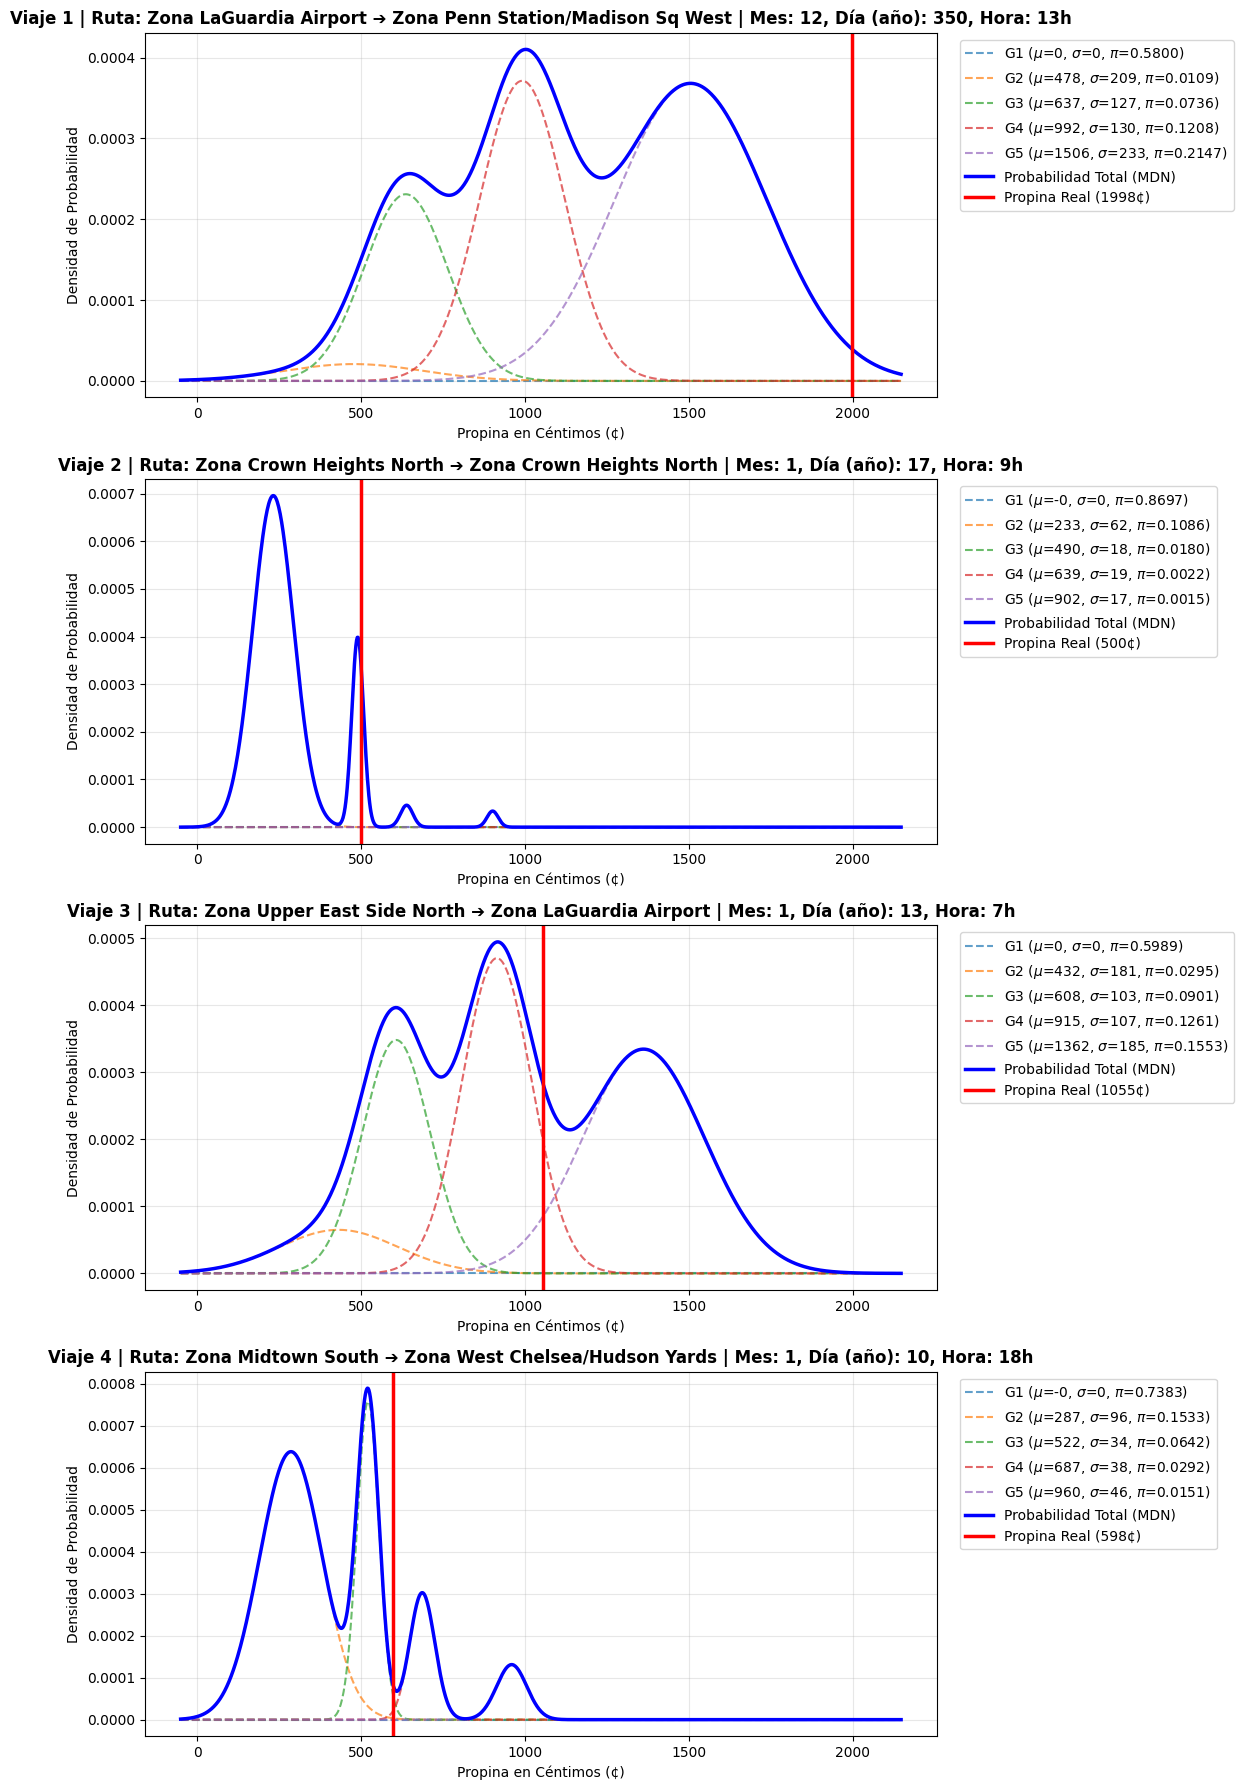

In [44]:
x_num_test = torch.tensor(
    df_test.select(num_cols).to_numpy(), dtype=torch.float32, device=device
)
x_temp_test = torch.tensor(
    df_test.select(temp_cols).to_numpy(), dtype=torch.float32, device=device
)
target_test = torch.tensor(
    df_test.select(target_col).to_numpy(), dtype=torch.float32, device=device
)
cat_data_test = {
    col: torch.tensor(df_test[col].to_numpy(), dtype=torch.long, device=device)
    for col in cat_cols
}


mascara_propinas = target_test.squeeze() > 300

x_num_con_propina = x_num_test[mascara_propinas]
x_temp_con_propina = x_temp_test[mascara_propinas]
target_con_propina = target_test[mascara_propinas]

cat_con_propina = {
    col: tensor[mascara_propinas] for col, tensor in cat_data_test.items()
}

plot_mdn_predictions_real(
    modelo1,
    x_num_con_propina[:4],
    {k: v[:4] for k, v in cat_con_propina.items()},
    x_temp_con_propina[:4],
    target_con_propina[:4],
    num_samples=4,
)

try:
    del x_num_test, x_temp_test, target_test, cat_data_test
    del x_num_con_propina, x_temp_con_propina, target_con_propina, cat_con_propina
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

### Funciones para guardar y cargar modelos

In [29]:
def guardar_modelo_mdn(
    modelo, params, nombre_modelo: str, ruta_archivo=path / "models/model_objects_tip/"
):
    """
    Extrae los pesos matemáticos de la MDN y los guarda en disco.
    Importante indicar los parámetros con los que se instanció el modelo.
    """
    # Nos aseguramos de que el directorio existe

    ruta_archivo.mkdir(parents=True, exist_ok=True)

    # Guardamos el diccionario de pesos
    torch.save(modelo.state_dict(), ruta_archivo / f"{nombre_modelo}.pth")

    with open(ruta_archivo / f"{nombre_modelo}_params.json", "w") as fp:
        json.dump(params, fp)

    print(f"💾 ¡Modelo guardado con éxito en: {ruta_archivo}!")


def cargar_modelo_mdn(
    clase_modelo, nombre_modelo, ruta_archivo=path / "models/model_objects_tip/"
):
    """
    Importante que exista en la ruta nombre_modelo.pth y nombre_modelo_params.json
    Importante que esté definido device
    """
    print(f"Cargando modelo desde {ruta_archivo}...")

    with open(ruta_archivo / f"{nombre_modelo}_params.json") as f:
        kwargs_modelo = json.load(f)

    # 1. Instanciamos el "esqueleto" vacío de la red
    modelo_recuperado = clase_modelo(**kwargs_modelo)

    # 2. Cargamos los pesos desde el disco, mapeándolos al dispositivo actual
    pesos = torch.load(
        ruta_archivo / f"{nombre_modelo}.pth", map_location=device, weights_only=True
    )

    # 3. Inyectamos los pesos en el esqueleto
    modelo_recuperado.load_state_dict(pesos)

    # 4. Lo movemos a la GPU/CPU y lo ponemos en modo evaluación por defecto
    modelo_recuperado.to(device)
    modelo_recuperado.eval()

    print("✅ ¡Modelo reconstruido y listo para predecir!")
    return modelo_recuperado

In [47]:
guardar_modelo_mdn(
    modelo1,
    {
        "num_numeric": len(num_cols),
        "cat_vocab_sizes": cat_vocab_sizes,
        "num_gaussians": 5,
        "hidden_dim": 128,
        "dropout_rate": 0.2,
    },
    "mdn_v1",
)

💾 ¡Modelo guardado con éxito en: /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip!


In [ ]:
# -- CARGAR EL MODELO GUARDADO --
# modelo1 = cargar_modelo_mdn(TaxiTipMDN, "mdn_v1")

Cargando modelo desde /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip...
✅ ¡Modelo reconstruido y listo para predecir!


### Búsqueda de hiperparámetros

In [49]:
x_num_gpu = torch.tensor(
    df_train.select(num_cols).to_numpy(), dtype=torch.float32, device=device
)
x_temp_gpu = torch.tensor(
    df_train.select(temp_cols).to_numpy(), dtype=torch.float32, device=device
)
target_gpu = torch.tensor(
    df_train.select(target_col).to_numpy(), dtype=torch.float32, device=device
)
cat_data_gpu = {
    col: torch.tensor(df_train[col].to_numpy(), dtype=torch.long, device=device)
    for col in cat_cols
}
x_num_val = torch.tensor(
    df_val.select(num_cols).to_numpy(), dtype=torch.float32, device=device
)
x_temp_val = torch.tensor(
    df_val.select(temp_cols).to_numpy(), dtype=torch.float32, device=device
)
target_val = torch.tensor(
    df_val.select(target_col).to_numpy(), dtype=torch.float32, device=device
)
cat_data_val = {
    col: torch.tensor(df_val[col].to_numpy(), dtype=torch.long, device=device)
    for col in cat_cols
}

In [ ]:
def objective(trial):
    num_gaussians = trial.suggest_int("num_gaussians", 2, 10)
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128, 256])
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    epochs = trial.suggest_int("epochs", 20, 60)

    # 2. Instanciamos el modelo con los parámetros sugeridos
    modelo_opt = TaxiTipMDN(
        num_numeric=len(num_cols),
        cat_vocab_sizes=cat_vocab_sizes,
        num_gaussians=num_gaussians,
        hidden_dim=hidden_dim,
        dropout_rate=dropout_rate,
    ).to(device)

    optimizer = optim.Adam(modelo_opt.parameters(), lr=lr, weight_decay=weight_decay)

    batch_size = 32768

    for epoch in range(epochs):
        modelo_opt.train()
        indices = torch.randperm(dataset_size, device=device)

        for start_idx in range(0, dataset_size, batch_size):
            batch_idx = indices[start_idx : start_idx + batch_size]

            b_num = x_num_gpu[batch_idx]
            b_temp = x_temp_gpu[batch_idx]
            b_target = target_gpu[batch_idx]
            b_cat = {col: cat_data_gpu[col][batch_idx] for col in cat_cols}

            optimizer.zero_grad()
            pi, mu, sigma = modelo_opt(b_num, b_cat, b_temp)
            loss = mdn_loss_function(pi, mu, sigma, b_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo_opt.parameters(), max_norm=1.0)
            optimizer.step()

        # Opcional: Optuna Pruning (Corta el trial temprano si va muy mal)
        # Esto ahorra muchísimo tiempo
        if epoch % 5 == 0:
            modelo_opt.eval()
            with torch.no_grad():
                pi_val, mu_val, sigma_val = modelo_opt(
                    x_num_val, cat_data_val, x_temp_val
                )
                val_loss = mdn_loss_function(
                    pi_val, mu_val, sigma_val, target_val
                ).item()

            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    modelo_opt.eval()
    with torch.no_grad():
        pi_val, mu_val, sigma_val = modelo_opt(x_num_val, cat_data_val, x_temp_val)
        final_val_loss = mdn_loss_function(pi_val, mu_val, sigma_val, target_val).item()

    return final_val_loss

In [49]:
# Crear el estudio de Optuna (direction='minimize' porque queremos el menor Loss/NLL)
study = optuna.create_study(direction="minimize", study_name="MDN_Taxis_Tuning")

print("Lanzando optimización de hiperparámetros con Optuna...")
# Ejecutar 40 pruebas (trials)
study.optimize(objective, n_trials=30)

print("\n🏆 ¡Optimización Terminada!")
print(f"Mejor NLL en Validación: {study.best_value:.4f}")
print("Mejores Hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-03-27 20:02:59,580] A new study created in memory with name: MDN_Taxis_Tuning


Lanzando optimización de hiperparámetros con Optuna...


[I 2026-03-27 20:03:31,586] Trial 0 finished with value: 0.7887944579124451 and parameters: {'num_gaussians': 7, 'hidden_dim': 64, 'dropout_rate': 0.00510437042102968, 'lr': 0.003378264290753895, 'weight_decay': 5.190670253496364e-05, 'epochs': 20}. Best is trial 0 with value: 0.7887944579124451.
[I 2026-03-27 20:05:56,454] Trial 1 finished with value: 7.098667144775391 and parameters: {'num_gaussians': 8, 'hidden_dim': 256, 'dropout_rate': 0.3405830312075741, 'lr': 0.058873333981683575, 'weight_decay': 0.0007109401947936934, 'epochs': 49}. Best is trial 0 with value: 0.7887944579124451.
[I 2026-03-27 20:07:20,884] Trial 2 finished with value: 2.807363748550415 and parameters: {'num_gaussians': 3, 'hidden_dim': 64, 'dropout_rate': 0.39092124752896756, 'lr': 0.011290159027433137, 'weight_decay': 0.00014317936338476087, 'epochs': 54}. Best is trial 0 with value: 0.7887944579124451.
[I 2026-03-27 20:07:57,045] Trial 3 finished with value: 0.7277494668960571 and parameters: {'num_gaussians


🏆 ¡Optimización Terminada!
Mejor NLL en Validación: 0.3048
Mejores Hiperparámetros encontrados:
  - num_gaussians: 8
  - hidden_dim: 64
  - dropout_rate: 0.2880466387782062
  - lr: 0.006384265991388851
  - weight_decay: 4.649814675802946e-06
  - epochs: 25


In [ ]:
def objective2(trial):
    # Subimos el techo para ver si 12 montañas son mejores que 8
    num_gaussians = trial.suggest_int("num_gaussians", 7, 12)

    # Nos quedamos solo con las arquitecturas ágiles
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128])

    # Acotamos el dropout alrededor del 0.28 que ganó
    dropout_rate = trial.suggest_float("dropout_rate", 0.15, 0.35)

    # Zoom en el Learning Rate (entre 0.001 y 0.01)
    lr = trial.suggest_float("lr", 1e-3, 1e-2, log=True)

    # Bajamos el suelo del Weight Decay para darle más libertad
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-5, log=True)

    # Dejamos las épocas cortas ya que converge rápido
    epochs = trial.suggest_int("epochs", 20, 40)

    # 2. Instanciamos el modelo con los parámetros sugeridos
    modelo_opt = TaxiTipMDN(
        num_numeric=len(num_cols),
        cat_vocab_sizes=cat_vocab_sizes,
        num_gaussians=num_gaussians,
        hidden_dim=hidden_dim,
        dropout_rate=dropout_rate,
    ).to(device)

    optimizer = optim.Adam(modelo_opt.parameters(), lr=lr, weight_decay=weight_decay)

    batch_size = 32768

    for epoch in range(epochs):
        modelo_opt.train()
        indices = torch.randperm(dataset_size, device=device)

        for start_idx in range(0, dataset_size, batch_size):
            batch_idx = indices[start_idx : start_idx + batch_size]

            b_num = x_num_gpu[batch_idx]
            b_temp = x_temp_gpu[batch_idx]
            b_target = target_gpu[batch_idx]
            b_cat = {col: cat_data_gpu[col][batch_idx] for col in cat_cols}

            optimizer.zero_grad()
            pi, mu, sigma = modelo_opt(b_num, b_cat, b_temp)
            loss = mdn_loss_function(pi, mu, sigma, b_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo_opt.parameters(), max_norm=1.0)
            optimizer.step()

        # Opcional: Optuna Pruning (Corta el trial temprano si va muy mal)
        # Esto ahorra muchísimo tiempo
        if epoch % 5 == 0:
            modelo_opt.eval()
            with torch.no_grad():
                pi_val, mu_val, sigma_val = modelo_opt(
                    x_num_val, cat_data_val, x_temp_val
                )
                val_loss = mdn_loss_function(
                    pi_val, mu_val, sigma_val, target_val
                ).item()

            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    modelo_opt.eval()
    with torch.no_grad():
        pi_val, mu_val, sigma_val = modelo_opt(x_num_val, cat_data_val, x_temp_val)
        final_val_loss = mdn_loss_function(pi_val, mu_val, sigma_val, target_val).item()

        # guardamos el mejor modelo
        if trial.number == 0 or final_val_loss < study.best_value:
            guardar_modelo_mdn(
                modelo_opt,
                {
                    "num_numeric": len(num_cols),
                    "cat_vocab_sizes": cat_vocab_sizes,
                    "num_gaussians": num_gaussians,
                    "hidden_dim": hidden_dim,
                    "dropout_rate": dropout_rate,
                },
                "mdn_optuna1",
            )

    try:
        del modelo_opt
    except NameError:
        pass

    gc.collect()
    torch.cuda.empty_cache()

    return final_val_loss

In [53]:
# Crear el estudio de Optuna (direction='minimize' porque queremos el menor Loss/NLL)
study = optuna.create_study(direction="minimize", study_name="MDN_Taxis_Tuning")

print("Lanzando optimización de hiperparámetros con Optuna...")
# Ejecutar 40 pruebas (trials)
study.optimize(objective2, n_trials=30)

print("\n🏆 ¡Optimización Terminada!")
print(f"Mejor NLL en Validación: {study.best_value:.4f}")
print("Mejores Hiperparámetros encontrados:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-03-28 13:19:42,291] A new study created in memory with name: MDN_Taxis_Tuning


Lanzando optimización de hiperparámetros con Optuna...


[I 2026-03-28 13:20:49,108] Trial 0 finished with value: -0.21019722521305084 and parameters: {'num_gaussians': 10, 'hidden_dim': 128, 'dropout_rate': 0.3400013090121288, 'lr': 0.007616167003222035, 'weight_decay': 6.413361251083333e-07, 'epochs': 33}. Best is trial 0 with value: -0.21019722521305084.


💾 ¡Modelo guardado con éxito en: /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip!


[I 2026-03-28 13:21:29,323] Trial 1 finished with value: -0.2825636565685272 and parameters: {'num_gaussians': 9, 'hidden_dim': 64, 'dropout_rate': 0.34692241022796944, 'lr': 0.0030163061191598134, 'weight_decay': 2.6877843647171247e-06, 'epochs': 24}. Best is trial 1 with value: -0.2825636565685272.


...

💾 ¡Modelo guardado con éxito en: /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip!


[I 2026-03-28 13:27:31,588] Trial 13 finished with value: -0.9715491533279419 and parameters: {'num_gaussians': 9, 'hidden_dim': 128, 'dropout_rate': 0.30949945089884123, 'lr': 0.004846046992066299, 'weight_decay': 2.2601842174063362e-07, 'epochs': 38}. Best is trial 13 with value: -0.9715491533279419.


💾 ¡Modelo guardado con éxito en: /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip!


[I 2026-03-28 13:27:54,202] Trial 14 pruned. 
[I 2026-03-28 13:27:56,146] Trial 15 pruned. 
[I 2026-03-28 13:29:09,585] Trial 16 finished with value: -0.637843906879425 and parameters: {'num_gaussians': 11, 'hidden_dim': 128, 'dropout_rate': 0.22785042637099184, 'lr': 0.005932221498202321, 'weight_decay': 1.090117544244878e-07, 'epochs': 36}. Best is trial 13 with value: -0.9715491533279419.
[I 2026-03-28 13:29:23,439] Trial 17 pruned. 
[I 2026-03-28 13:29:46,917] Trial 18 pruned. 
[I 2026-03-28 13:30:46,391] Trial 19 finished with value: -0.7147332429885864 and parameters: {'num_gaussians': 10, 'hidden_dim': 128, 'dropout_rate': 0.28512952933694563, 'lr': 0.0059432437787741, 'weight_decay': 1.0501354259000037e-07, 'epochs': 29}. Best is trial 13 with value: -0.9715491533279419.
[I 2026-03-28 13:30:48,539] Trial 20 pruned. 
[I 2026-03-28 13:31:10,621] Trial 21 pruned. 
[I 2026-03-28 13:31:12,584] Trial 22 pruned. 
[I 2026-03-28 13:31:14,588] Trial 23 pruned. 
[I 2026-03-28 13:31:35,882


🏆 ¡Optimización Terminada!
Mejor NLL en Validación: -0.9715
Mejores Hiperparámetros encontrados:
  - num_gaussians: 9
  - hidden_dim: 128
  - dropout_rate: 0.30949945089884123
  - lr: 0.004846046992066299
  - weight_decay: 2.2601842174063362e-07
  - epochs: 38


In [54]:
try:
    del (
        x_num_val,
        x_temp_val,
        target_val,
        cat_data_val,
        x_num_gpu,
        x_temp_gpu,
        target_gpu,
        cat_data_gpu,
    )
except NameError:
    pass

gc.collect()

torch.cuda.empty_cache()

print("🧹 Memoria de GPU liberada.")

🧹 Memoria de GPU liberada.


### Probamos cómo se comporta el modelo con menos features

In [17]:
t_cat = {
    col: torch.tensor(df_train[col].to_numpy(), dtype=torch.long, device=device)
    for col in cat_cols
}
t_x_temp = torch.tensor(
    df_train.select(temp_cols).to_numpy(), dtype=torch.float32, device=device
)
t_target = torch.tensor(
    df_train.select(target_col).to_numpy(), dtype=torch.float32, device=device
)
v_cat = {
    col: torch.tensor(df_val[col].to_numpy(), dtype=torch.long, device=device)
    for col in cat_cols
}
v_x_temp = torch.tensor(
    df_val.select(temp_cols).to_numpy(), dtype=torch.float32, device=device
)
target_val = torch.tensor(
    df_val.select(target_col).to_numpy(), dtype=torch.float32, device=device
)

In [32]:
def objective_feature_selection(trial):
    num_gaussians = 9
    hidden_dim = 128
    dropout_rate = 0.3
    lr = 0.004846
    weight_decay = 2.26e-07
    epochs = 35
    batch_size = 32768

    usar_coords_crudas = trial.suggest_categorical("usar_coords_crudas", [True, False])
    usar_dist_aeropuertos = trial.suggest_categorical(
        "usar_dist_aeropuertos", [True, False]
    )
    usar_delay = trial.suggest_categorical("usar_delay", [True, False])
    usar_adj_dist = trial.suggest_categorical("usar_adj_dist", [True, False])

    trial_num_cols = ["distance", "direction", "trip_duration_min"]

    # Si Optuna dice True, añadimos las coordenadas al saco
    if usar_coords_crudas:
        trial_num_cols.extend(
            [
                "pickup_latitude",
                "pickup_longitude",
                "dropoff_latitude",
                "dropoff_longitude",
            ]
        )

    # Si Optuna dice True, añadimos las distancias a zonas
    if usar_dist_aeropuertos:
        trial_num_cols.extend(
            [
                "pickup_dist_nyc",
                "dropoff_dist_nyc",
                "pickup_dist_chp",
                "dropoff_dist_chp",
                "pickup_dist_exp",
                "dropoff_dist_exp",
            ]
        )

    # Si Optuna dice True, metemos los IDs de las zonas (PULocationID, DOLocationID)
    if usar_delay:
        trial_num_cols.extend(["diff_eta", "delay_ratio"])

    if usar_adj_dist:
        trial_num_cols.append("adj_dist")

    # Train
    t_x_num = torch.tensor(
        df_train.select(trial_num_cols).to_numpy(), dtype=torch.float32, device=device
    )

    # Validacion
    v_x_num = torch.tensor(
        df_val.select(trial_num_cols).to_numpy(), dtype=torch.float32, device=device
    )

    # Modelo
    modelo_opt = TaxiTipMDN(
        num_numeric=len(trial_num_cols),
        cat_vocab_sizes=cat_vocab_sizes,
        num_gaussians=num_gaussians,
        hidden_dim=hidden_dim,
        dropout_rate=dropout_rate,
    ).to(device)

    # Inyectamos las medias y stds específicas de ESTAS columnas numéricas
    medias_trial = df_train.select(trial_num_cols).mean().to_numpy()[0]
    stds_trial = df_train.select(trial_num_cols).std().to_numpy()[0]
    modelo_opt.set_scaler_stats(medias_trial, stds_trial)

    optimizer = optim.AdamW(modelo_opt.parameters(), lr=lr, weight_decay=weight_decay)

    dataset_size = len(t_target)

    for epoch in range(epochs):
        modelo_opt.train()
        indices = torch.randperm(dataset_size, device=device)

        for start_idx in range(0, dataset_size, batch_size):
            batch_idx = indices[start_idx : start_idx + batch_size]

            b_num = t_x_num[batch_idx]
            b_temp = t_x_temp[batch_idx]
            b_target = t_target[batch_idx]
            b_cat = {col: t_cat[col][batch_idx] for col in cat_cols}

            optimizer.zero_grad()
            pi, mu, sigma = modelo_opt(b_num, b_cat, b_temp)
            loss = mdn_loss_function(pi, mu, sigma, b_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo_opt.parameters(), max_norm=1.0)
            optimizer.step()

    modelo_opt.eval()
    with torch.no_grad():
        pi_val, mu_val, sigma_val = modelo_opt(v_x_num, v_cat, v_x_temp)
        final_val_loss = mdn_loss_function(pi_val, mu_val, sigma_val, target_val).item()

        # guardamos el mejor modelo
        if trial.number == 0 or final_val_loss < study_fs.best_value:
            guardar_modelo_mdn(
                modelo_opt,
                {
                    "num_numeric": len(trial_num_cols),
                    "cat_vocab_sizes": cat_vocab_sizes,
                    "num_gaussians": num_gaussians,
                    "hidden_dim": hidden_dim,
                    "dropout_rate": dropout_rate,
                },
                f"mdn_opt_{trial_num_cols}",
            )

    # Limpieza
    try:
        del t_x_num, v_x_num
        del modelo_opt
    except NameError:
        pass

    gc.collect()
    torch.cuda.empty_cache()

    return final_val_loss

In [33]:
# Lanzar el estudio
study_fs = optuna.create_study(direction="minimize", study_name="Feature_Selection_MDN")
study_fs.optimize(objective_feature_selection, n_trials=25)

print("🏆 Mejores características encontradas:")
for key, value in study_fs.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-03-29 12:20:01,976] A new study created in memory with name: Feature_Selection_MDN
[I 2026-03-29 12:21:11,010] Trial 0 finished with value: -1.1800751686096191 and parameters: {'usar_coords_crudas': False, 'usar_dist_aeropuertos': True, 'usar_delay': True, 'usar_adj_dist': True}. Best is trial 0 with value: -1.1800751686096191.


💾 ¡Modelo guardado con éxito en: /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip!


[I 2026-03-29 12:22:16,577] Trial 1 finished with value: -0.32588255405426025 and parameters: {'usar_coords_crudas': False, 'usar_dist_aeropuertos': False, 'usar_delay': False, 'usar_adj_dist': False}. Best is trial 0 with value: -1.1800751686096191.
[I 2026-03-29 12:23:28,032] Trial 2 finished with value: -1.5113472938537598 and parameters: {'usar_coords_crudas': True, 'usar_dist_aeropuertos': False, 'usar_delay': True, 'usar_adj_dist': True}. Best is trial 2 with value: -1.5113472938537598.


💾 ¡Modelo guardado con éxito en: /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip!


[I 2026-03-29 12:24:40,409] Trial 3 finished with value: -0.8118808269500732 and parameters: {'usar_coords_crudas': True, 'usar_dist_aeropuertos': False, 'usar_delay': True, 'usar_adj_dist': True}. Best is trial 2 with value: -1.5113472938537598.
[I 2026-03-29 12:25:51,474] Trial 4 finished with value: -1.4965111017227173 and parameters: {'usar_coords_crudas': True, 'usar_dist_aeropuertos': False, 'usar_delay': True, 'usar_adj_dist': True}. Best is trial 2 with value: -1.5113472938537598.
[I 2026-03-29 12:27:04,061] Trial 5 finished with value: -1.0582009553909302 and parameters: {'usar_coords_crudas': False, 'usar_dist_aeropuertos': True, 'usar_delay': False, 'usar_adj_dist': False}. Best is trial 2 with value: -1.5113472938537598.
[I 2026-03-29 12:28:18,558] Trial 6 finished with value: -1.1504616737365723 and parameters: {'usar_coords_crudas': True, 'usar_dist_aeropuertos': True, 'usar_delay': True, 'usar_adj_dist': True}. Best is trial 2 with value: -1.5113472938537598.
[I 2026-03-

💾 ¡Modelo guardado con éxito en: /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip!


[I 2026-03-29 12:30:38,123] Trial 8 finished with value: -1.4096604585647583 and parameters: {'usar_coords_crudas': False, 'usar_dist_aeropuertos': True, 'usar_delay': True, 'usar_adj_dist': True}. Best is trial 7 with value: -1.5490198135375977.


💾 ¡Modelo guardado con éxito en: /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip!


[I 2026-03-29 12:31:48,126] Trial 9 finished with value: -1.6633071899414062 and parameters: {'usar_coords_crudas': False, 'usar_dist_aeropuertos': False, 'usar_delay': False, 'usar_adj_dist': False}. Best is trial 9 with value: -1.6633071899414062.
[I 2026-03-29 12:32:56,993] Trial 10 finished with value: -0.41063380241394043 and parameters: {'usar_coords_crudas': False, 'usar_dist_aeropuertos': False, 'usar_delay': False, 'usar_adj_dist': False}. Best is trial 9 with value: -1.6633071899414062.
[I 2026-03-29 12:34:05,417] Trial 11 finished with value: -0.3579762876033783 and parameters: {'usar_coords_crudas': False, 'usar_dist_aeropuertos': False, 'usar_delay': False, 'usar_adj_dist': False}. Best is trial 9 with value: -1.6633071899414062.
[I 2026-03-29 12:35:10,850] Trial 12 finished with value: -1.3054654598236084 and parameters: {'usar_coords_crudas': False, 'usar_dist_aeropuertos': False, 'usar_delay': False, 'usar_adj_dist': False}. Best is trial 9 with value: -1.66330718994140

🏆 Mejores características encontradas:
  - usar_coords_crudas: False
  - usar_dist_aeropuertos: False
  - usar_delay: False
  - usar_adj_dist: False


Aunque con mayor inestabilidad, el modelo puede funcionar sin las variables extra.

In [ ]:
# Limpieza
try:
    del t_cat, t_x_temp, t_target, v_cat, v_x_temp, target_val
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

### Evaluación en test

In [34]:
modelo_final = cargar_modelo_mdn(
    TaxiTipMDN, "mdn_opt_['distance', 'direction', 'trip_duration_min']"
)

Cargando modelo desde /home/yo/UCM_Trabajos/C-ity-enjoyers/models/model_objects_tip...
✅ ¡Modelo reconstruido y listo para predecir!


In [39]:
def evaluar_modelo_test(
    modelo, df_test, num_cols, cat_cols, temp_cols, target_col, device
):
    print("⏳ Preparando datos de Test y ejecutando inferencia...")

    t_x_num = torch.tensor(
        df_test.select(num_cols).to_numpy(), dtype=torch.float32, device=device
    )
    t_x_temp = torch.tensor(
        df_test.select(temp_cols).to_numpy(), dtype=torch.float32, device=device
    )
    t_cat = {
        col: torch.tensor(df_test[col].to_numpy(), dtype=torch.long, device=device)
        for col in cat_cols
    }
    target_test = torch.tensor(
        df_test.select(target_col).to_numpy(), dtype=torch.float32, device=device
    )

    # El target lo dejamos en Numpy para compararlo luego (en céntimos)
    target_test_centimos = df_test.select(target_col).to_numpy().flatten()

    # Inferencia
    modelo.eval()
    with torch.no_grad():
        pi_test, mu_test, sigma_test = modelo(t_x_num, t_cat, t_x_temp)
        final_test_loss = mdn_loss_function(
            pi_test, mu_test, sigma_test, target_test
        ).item()

    # Limpieza
    try:
        del t_cat, t_x_temp, t_x_num, target_test
    except NameError:
        pass

    gc.collect()
    torch.cuda.empty_cache()

    # Pasamos los resultados a CPU y Numpy
    pi_np = pi_test.cpu().numpy()
    mu_np = mu_test.cpu().numpy()

    # COLAPSAR LA MDN: Calculamos el Valor Esperado
    predicciones_centimos = np.sum(pi_np * mu_np, axis=1)

    # Convertir a Dólares
    predicciones_dolares = predicciones_centimos / 100.0
    target_dolares = target_test_centimos / 100.0

    # Calcular Métricas Clásicas
    mae = mean_absolute_error(target_dolares, predicciones_dolares)
    rmse = np.sqrt(mean_squared_error(target_dolares, predicciones_dolares))

    # Extra: ¿Qué pasa si el modelo predice propinas negativas por error matemático?
    # Lo capeamos a 0 (Nadie te quita dinero por un viaje)
    predicciones_dolares_clipped = np.clip(predicciones_dolares, a_min=0, a_max=None)
    mae_clipped = mean_absolute_error(target_dolares, predicciones_dolares_clipped)

    print("\n🏆 RESULTADOS FINALES EN TEST (DÓLARES) 🏆")
    print("-" * 45)
    print(f"MAE Puro:              ${mae:.4f}")
    print(f"MAE (Capeado a $0):    ${mae_clipped:.4f}")
    print(f"RMSE:                  ${rmse:.4f}")
    print(f"Test mdn LOSS:        ${final_test_loss:.4f}")
    print("-" * 45)

    return target_dolares, predicciones_dolares_clipped


num_cols_final = ["distance", "direction", "trip_duration_min"]
y_real, y_pred = evaluar_modelo_test(
    modelo_final, df_test, num_cols_final, cat_cols, temp_cols, target_col, device
)

⏳ Preparando datos de Test y ejecutando inferencia...

🏆 RESULTADOS FINALES EN TEST (DÓLARES) 🏆
---------------------------------------------
MAE Puro:              $1.5866
MAE (Capeado a $0):    $1.5866
RMSE:                  $2.9853
Test mdn LOSS:        $-2.5295
---------------------------------------------


El MAE, RMSE son estadísticos que poco nos quieren decir ya que este tipo de modelo se centra en distribuciones de probabilidad, no es determinista. Es decir, encontramos montañas de probabilidad en las propinas más comunes.

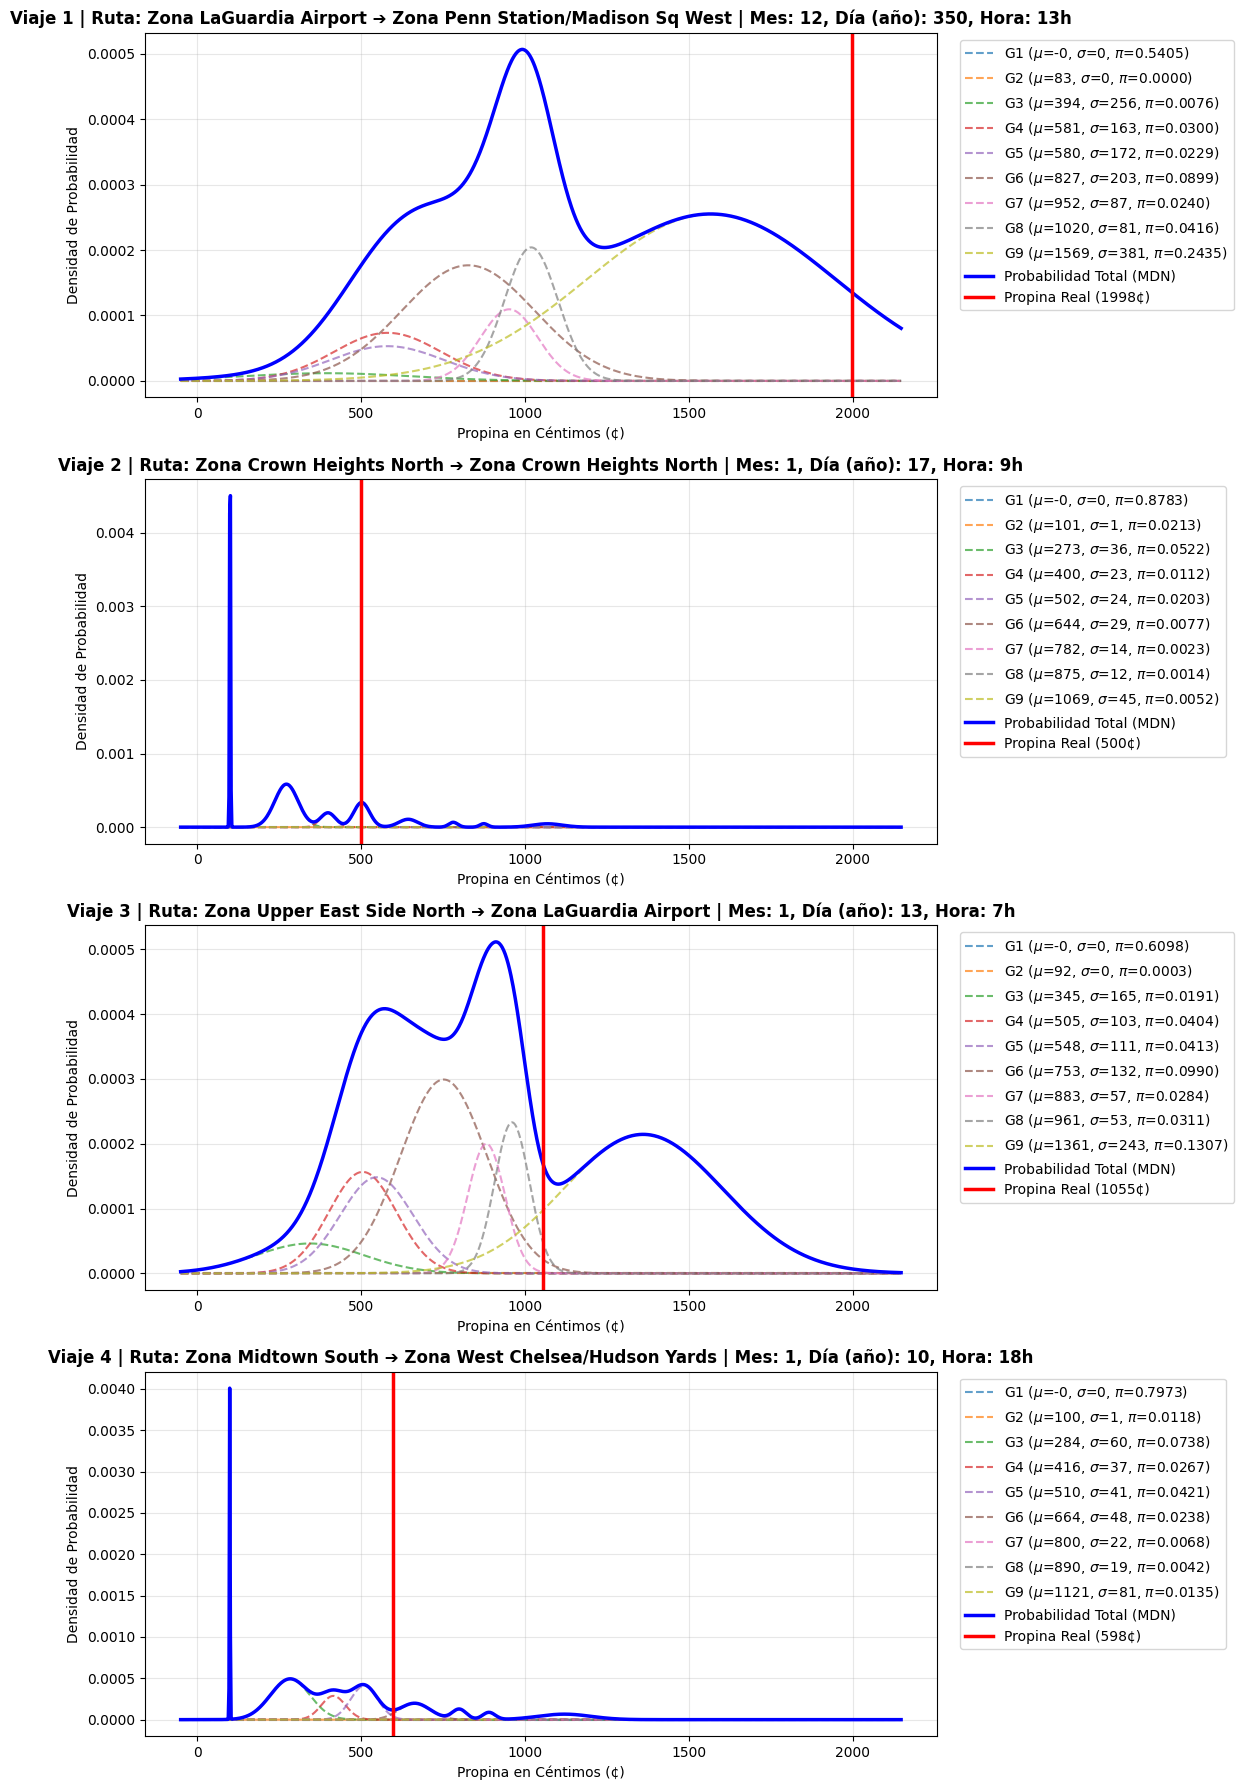

In [52]:
x_num_test = torch.tensor(
    df_test.select(num_cols_final).to_numpy(), dtype=torch.float32, device=device
)
x_temp_test = torch.tensor(
    df_test.select(temp_cols).to_numpy(), dtype=torch.float32, device=device
)
target_test = torch.tensor(
    df_test.select(target_col).to_numpy(), dtype=torch.float32, device=device
)
cat_data_test = {
    col: torch.tensor(df_test[col].to_numpy(), dtype=torch.long, device=device)
    for col in cat_cols
}


mascara_propinas = target_test.squeeze() > 300

x_num_con_propina = x_num_test[mascara_propinas]
x_temp_con_propina = x_temp_test[mascara_propinas]
target_con_propina = target_test[mascara_propinas]

cat_con_propina = {
    col: tensor[mascara_propinas] for col, tensor in cat_data_test.items()
}

plot_mdn_predictions_real(
    modelo_final,
    x_num_con_propina[:4],
    {k: v[:4] for k, v in cat_con_propina.items()},
    x_temp_con_propina[:4],
    target_con_propina[:4],
    num_samples=4,
)

try:
    del x_num_test, x_temp_test, target_test, cat_data_test
    del x_num_con_propina, x_temp_con_propina, target_con_propina, cat_con_propina
except NameError:
    pass

gc.collect()
torch.cuda.empty_cache()

In [ ]:
try:
    del (
        x_num_val,
        x_temp_val,
        target_val,
        cat_data_val,
        x_num_gpu,
        x_temp_gpu,
        target_gpu,
        cat_data_gpu,
    )
    del modelo_opt, modelo  # Si quieres borrar un modelo antiguo
except NameError:
    pass

gc.collect()

torch.cuda.empty_cache()

print("🧹 Memoria de GPU liberada.")

🧹 Memoria de GPU liberada.
